In [1]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(name)s: %(message)s",
    datefmt="%H:%M:%S",
)

import tanglepack
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
def henon_map(point):
    """
    Defines the henon map for binary horshoe parameters to test basic functionality
    """

    k, b = (2, 1)

    x = point[0]
    y = point[1]

    return np.array([y - k + x**2, -b * x])


def henon_map_inverse(point):
    """Defines the inverse henon map for"""

    k, b = (2, 1)

    x = point[0]
    y = point[1]

    return np.array([-y / b, x + k - (y**2) / (b**2)])

In [3]:
"""initialize the manifolds

Every cell below rebuilds the nested tangle from scratch with `fresh()`, so the
notebook runs top to bottom without one cell's growth leaking into the next.
"""


def fresh():
    """A workbench holding the period-3 orbit and the period-1 saddle, both initialized."""

    workbench = tanglepack.TangleWorkbench(henon_map, henon_map_inverse)

    # find the fixed points
    fixed_point = workbench.construct_fixed_point([[0, 1], [-1, 0], [-1, 1]])
    fixed_point_zero = workbench.construct_fixed_point([4, -4])

    # orient the eigenvectors properly
    workbench.orient_eigenvectors(
        fixed_point, {"unstable": np.array([0, -1]), "stable": np.array([-1, -1])}
    )
    workbench.orient_eigenvectors(
        fixed_point_zero, {"unstable": np.array([-1, 0]), "stable": np.array([0, 1])}
    )

    # get the initial segments
    workbench.initialize_both_manifolds(fixed_point)
    workbench.initialize_both_manifolds(fixed_point_zero)

    return workbench, fixed_point, fixed_point_zero


workbench, fixed_point, fixed_point_zero = fresh()

print(f"The fixed point is: {fixed_point.coordinates}")

The fixed point is: [[ 0.  1.]
 [-1.  0.]
 [-1.  1.]]


04:48:40 WARNING  matplotlib.axes._base: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


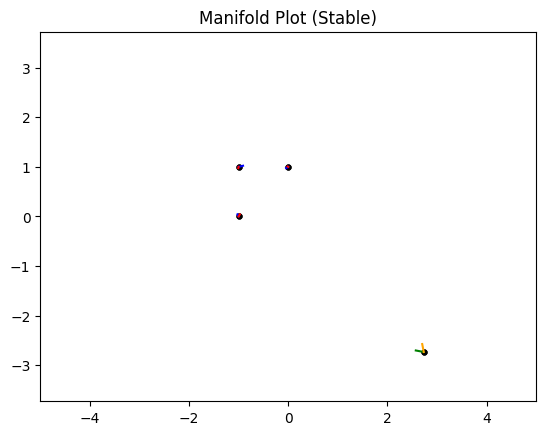

In [4]:
"""growing based on the number of iterates"""

workbench, fixed_point, fixed_point_zero = fresh()

workbench.grow_n_times(fixed_point, "unstable", num_iterations=7)
workbench.plot_tangle(fixed_point, "unstable")

workbench.grow_n_times(fixed_point, "stable", num_iterations=6)
workbench.plot_tangle(fixed_point, "stable", color="r")

workbench.grow_n_times(fixed_point_zero, "unstable", num_iterations=6)
workbench.plot_tangle(fixed_point_zero, "unstable", color="green")

workbench.grow_n_times(fixed_point_zero, "stable", num_iterations=6)
workbench.plot_tangle(fixed_point_zero, "stable", color="orange")

plt.xlim([-5, 5])
plt.ylim([-5, 5])

plt.show()

04:48:40 WARNING  matplotlib.axes._base: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


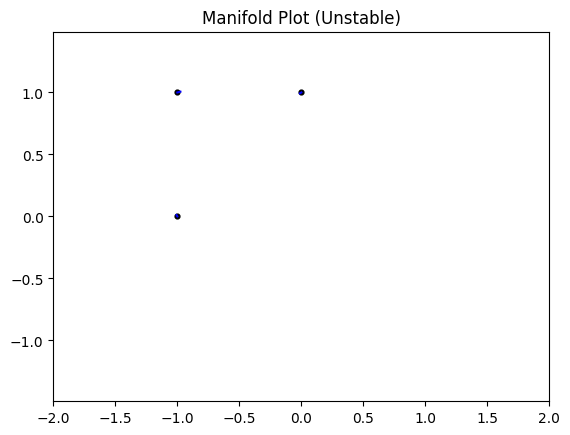

In [5]:
"""growing the inner (period-3) unstable manifold only"""

workbench, fixed_point, fixed_point_zero = fresh()

workbench.grow_n_times(fixed_point, "unstable", num_iterations=6)
workbench.plot_tangle(fixed_point, "unstable")

plt.xlim([-2, 2])
plt.ylim([-2, 2])

plt.show()

04:48:40 WARNING  matplotlib.axes._base: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


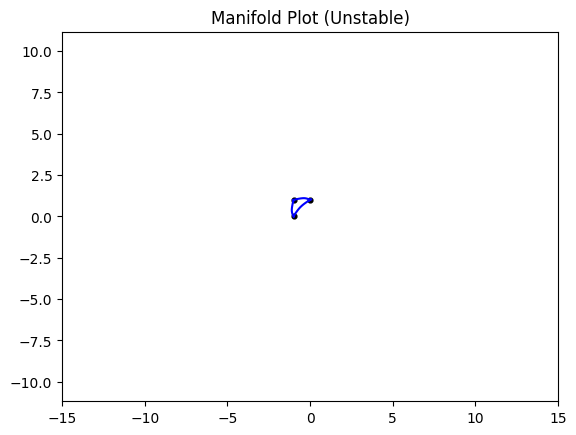

In [6]:
"""growing until the desired cdist is reached

A period-3 orbit grows more slowly per iteration than a period-1 saddle, so the
default cap of 10 iterations is not enough to reach length 50 here.
"""

workbench, fixed_point, fixed_point_zero = fresh()

workbench.grow_until_arclength(
    fixed_point, "unstable", length=50, max_iterations=20
)
workbench.plot_tangle(fixed_point, "unstable")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()

04:48:40 WARNING  matplotlib.axes._base: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


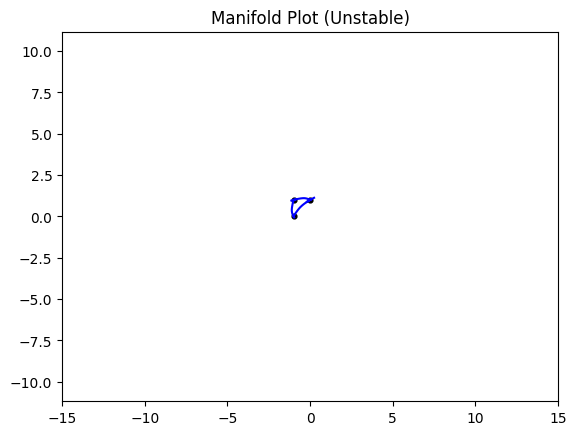

In [7]:
"growing until the manifold turns around"

workbench, fixed_point, fixed_point_zero = fresh()

workbench.grow_until_turnaround(fixed_point, "unstable", max_iterations=20)
workbench.plot_tangle(fixed_point, "unstable")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()

04:48:40 INFO     tanglepack.numerics.TangleWorkbench: current intersections 3


04:48:40 WARNING  matplotlib.axes._base: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


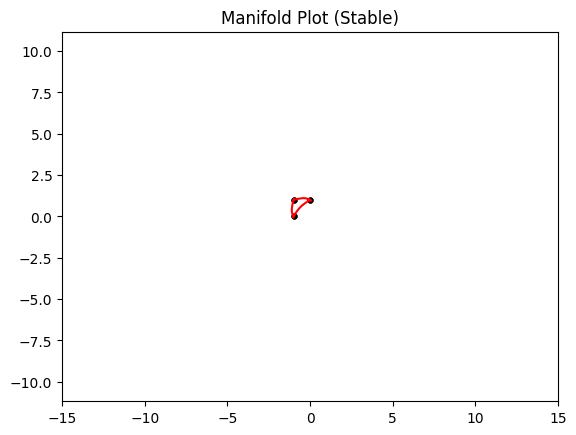

In [8]:
"growing until one manifold intersects the other"

workbench, fixed_point, fixed_point_zero = fresh()

workbench.grow_until_arclength(fixed_point, "stable", length=50, max_iterations=20)
workbench.grow_until_intersection(fixed_point, "unstable", max_iterations=20)

workbench.plot_tangle(fixed_point, "unstable")
workbench.plot_tangle(fixed_point, "stable", color="r")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()